<a href="https://colab.research.google.com/github/adilsaleem007/Python-Basics-Assignment/blob/main/Assignment_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


In [2]:
# Load the Dataset

df = pd.read_csv('/content/car details v4.csv')
df.head(), df.shape

(            Make                            Model    Price  Year  Kilometer  \
 0          Honda              Amaze 1.2 VX i-VTEC   505000  2017      87150   
 1  Maruti Suzuki                  Swift DZire VDI   450000  2014      75000   
 2        Hyundai             i10 Magna 1.2 Kappa2   220000  2011      67000   
 3         Toyota                         Glanza G   799000  2019      37500   
 4         Toyota  Innova 2.4 VX 7 STR [2016-2020]  1950000  2018      69000   
 
   Fuel Type Transmission   Location   Color   Owner Seller Type   Engine  \
 0    Petrol       Manual       Pune    Grey   First   Corporate  1198 cc   
 1    Diesel       Manual   Ludhiana   White  Second  Individual  1248 cc   
 2    Petrol       Manual    Lucknow  Maroon   First  Individual  1197 cc   
 3    Petrol       Manual  Mangalore     Red   First  Individual  1197 cc   
 4    Diesel       Manual     Mumbai    Grey   First  Individual  2393 cc   
 
             Max Power              Max Torque Drivetr

In [3]:
#Information on the data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2059 entries, 0 to 2058
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Make                2059 non-null   object 
 1   Model               2059 non-null   object 
 2   Price               2059 non-null   int64  
 3   Year                2059 non-null   int64  
 4   Kilometer           2059 non-null   int64  
 5   Fuel Type           2059 non-null   object 
 6   Transmission        2059 non-null   object 
 7   Location            2059 non-null   object 
 8   Color               2059 non-null   object 
 9   Owner               2059 non-null   object 
 10  Seller Type         2059 non-null   object 
 11  Engine              1979 non-null   object 
 12  Max Power           1979 non-null   object 
 13  Max Torque          1979 non-null   object 
 14  Drivetrain          1923 non-null   object 
 15  Length              1995 non-null   float64
 16  Width 

In [4]:
#Statistical description
df.describe()

,Price,Year,Kilometer,Length,Width,Height,Seating Capacity,Fuel Tank Capacity
count,2.059000e+03,2059.000000,2.059000e+03,1995.000000,1995.000000,1995.000000,1995.000000,1946.000000
mean,1.702992e+06,2016.425449,5.422471e+04,4280.860652,1767.991980,1591.735338,5.306266,52.002210
std,2.419881e+06,3.363564,5.736172e+04,442.458507,135.265825,136.073956,0.822170,15.110198
min,4.900000e+04,1988.000000,0.000000e+00,3099.000000,1475.000000,1165.000000,2.000000,15.000000
25%,4.849990e+05,2014.000000,2.900000e+04,3985.000000,1695.000000,1485.000000,5.000000,41.250000
50%,8.250000e+05,2017.000000,5.000000e+04,4370.000000,1770.000000,1545.000000,5.000000,50.000000
75%,1.925000e+06,2019.000000,7.200000e+04,4629.000000,1831.500000,1675.000000,5.000000,60.000000
max,3.500000e+07,2022.000000,2.000000e+06,5569.000000,2220.000000,1995.000000,8.000000,105.000000


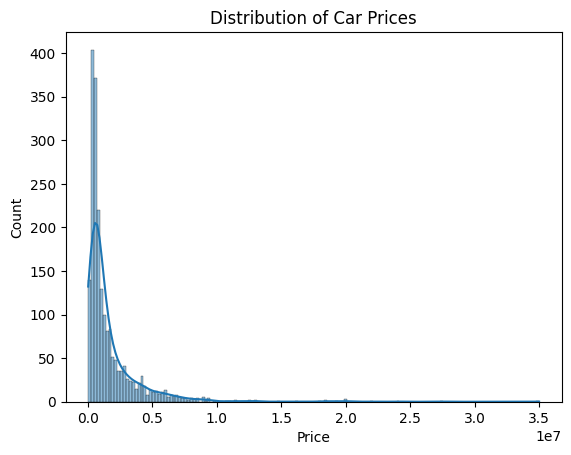

In [5]:
# Target Variable Distribution
plt.figure()
sns.histplot(df['Price'], kde=True)
plt.title('Distribution of Car Prices')
plt.show()

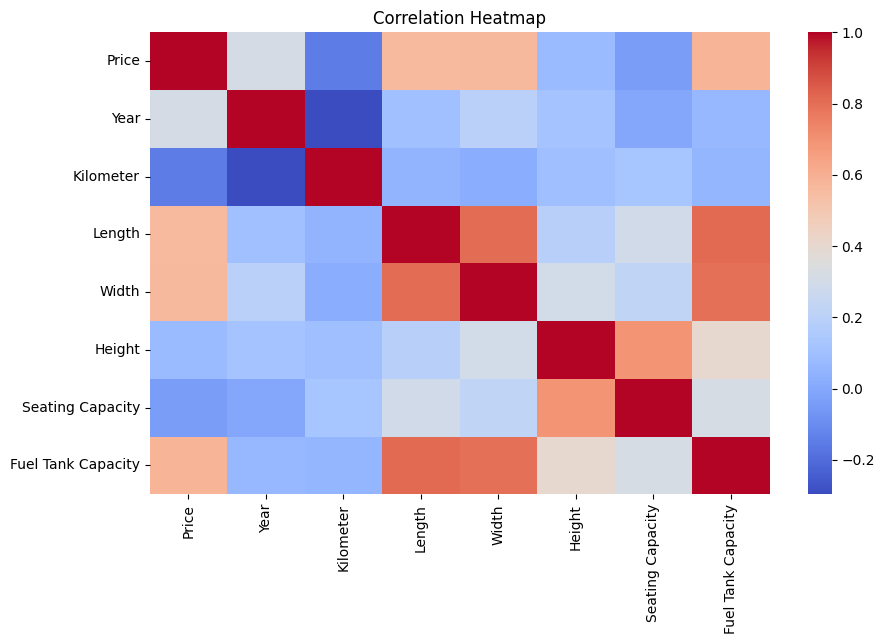

In [6]:
# Correlation Heatmap

plt.figure(figsize=(10,6))
sns.heatmap(df.select_dtypes(include=np.number).corr(), cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [7]:
#Data Preprocessing
#Missing Value Handling

for col in df.select_dtypes(include=np.number).columns:
    df[col].fillna(df[col].median(), inplace=True)

for col in df.select_dtypes(include='object').columns:
    df[col].fillna(df[col].mode()[0], inplace=True)

/tmp/ipython-input-210501368.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
/tmp/ipython-input-210501368.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 

In [8]:
# Separate Features and Target Variable

X = df.drop('Price', axis=1)
y = df['Price']

In [9]:
# Identify Numerical and Categorical Columns

num_features = X.select_dtypes(include=np.number).columns
cat_features = X.select_dtypes(include='object').columns

num_features, cat_features

(Index(['Year', 'Kilometer', 'Length', 'Width', 'Height', 'Seating Capacity',
        'Fuel Tank Capacity'],
       dtype='object'),
 Index(['Make', 'Model', 'Fuel Type', 'Transmission', 'Location', 'Color',
        'Owner', 'Seller Type', 'Engine', 'Max Power', 'Max Torque',
        'Drivetrain'],
       dtype='object'))

In [10]:

# Preprocessing Pipelines

numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_features),
        ('cat', categorical_transformer, cat_features)
    ]
)

In [11]:
#Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [12]:
#Model Development – Linear Regression

model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  Index(['Year', 'Kilometer', 'Length', 'Width', 'Height', 'Seating Capacity',
       'Fuel Tank Capacity'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['Make', 'Model', 'Fuel Type', 'Transmission', 'Location', 'Color',
       'Owner', 'Seller Type', 'Engine', 'Max Power', 'Max Torque',
       'Drivetrain'],
      dtype='object'))])),
                ('regressor', LinearRegression())])

In [13]:
#Model Evaluation

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

mse, r2

(2825638819843.551, 0.5955447055620018)

###  **Model Interpretation**

- A Linear Regression model was developed to predict the selling price of used cars based on technical specifications, usage history, and seller information.
- The model achieved an R-squared value of approximately 0.60, indicating that around 60% of the variation in car prices is explained by the selected features.
- Year of manufacture and kilometers driven have a strong influence on car price.
- Engine capacity, maximum power, and torque contribute positively to the predicted price.
- Categorical variables such as make, fuel type, and transmission also play a significant role in car valuation.
- The Mean Squared Error is relatively high due to the large scale of price values in INR.
- Overall, the model demonstrates reasonable predictive performance and can be improved using more advanced regression techniques.
